<a href="https://colab.research.google.com/github/Tilak46-R/Paisabazaar-Banking-Fraud-Analysis/blob/main/Paisabazaar_Banking_Fraud_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/content/dataset.csv')

In [8]:
data = df.copy()

In [9]:
data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [10]:
data.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,155625,37932,4,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.663572,378.0,No,35.104023,24.028477,High_spent_Large_value_payments,479.866228,Poor
99996,155626,37932,5,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,40.565631,379.0,No,35.104023,24.028477,High_spent_Medium_value_payments,496.651610,Poor
99997,155627,37932,6,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,41.255522,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,155628,37932,7,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,33.638208,381.0,No,35.104023,24.028477,Low_spent_Large_value_payments,319.164979,Standard
99999,155629,37932,8,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.192463,382.0,No,35.104023,24.028477,High_spent_Medium_value_payments,393.673696,Poor


In [11]:
data.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [13]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
99995,False
99996,False
99997,False
99998,False


In [14]:
null_values = data.isnull().sum()

In [15]:
null_values

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [16]:
Age_group = data['Age'].value_counts().sort_values(ascending =  False)

In [17]:
Age_group

,count
Age,
38.0,3070
28.0,3045
31.0,3037
26.0,3025
32.0,2969
36.0,2953
25.0,2952
27.0,2951
35.0,2940


In [18]:
top_age_group = Age_group.head()

In [19]:
top_age_group

,count
Age,
38.0,3070
28.0,3045
31.0,3037
26.0,3025
32.0,2969


AGE GROUP WITH MAX DEFAULT

<Axes: xlabel='Age'>

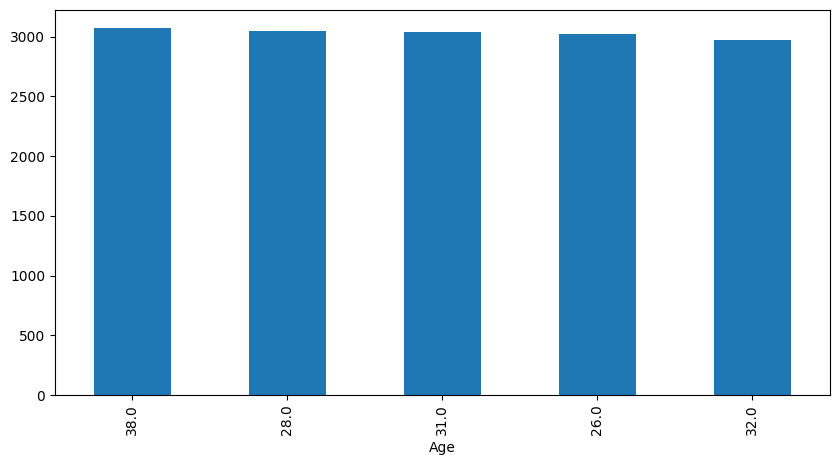

In [20]:
top_age_group.plot(kind = 'bar',figsize = (10,5))

In [21]:
Occupation = data['Occupation'].value_counts()

In [22]:
top_5_occupation = Occupation.sort_values(ascending = False).head()

<Axes: xlabel='Occupation'>

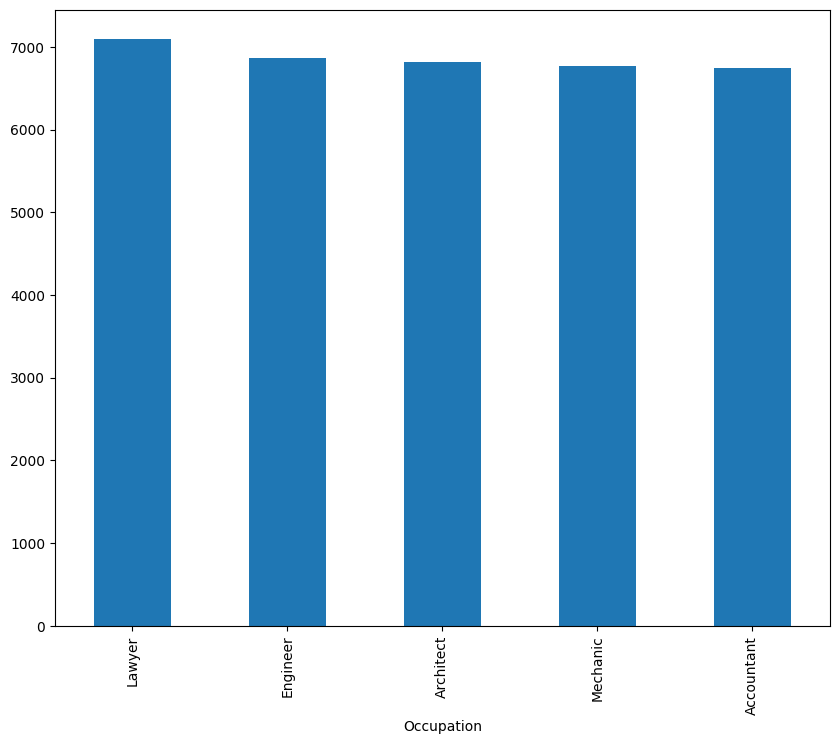

In [23]:
top_5_occupation.plot(kind = 'bar', figsize =(10,8))

In [24]:
Annual_Income = data.groupby('Occupation')['Annual_Income'].value_counts().sort_values(ascending = False)

In [25]:
Annual_Income

Occupation    Annual_Income
Entrepreneur  109945.32        16
Mechanic      118151.16         8
              118244.84         8
              118831.62         8
              119568.15         8
                               ..
Engineer      130091.08         8
              130169.92         8
              130210.20         8
              131760.30         8
              124782.20         8
Name: count, Length: 12499, dtype: int64

In [26]:
 data.groupby('Monthly_Inhand_Salary')['Total_EMI_per_month'].mean()

,Total_EMI_per_month
Monthly_Inhand_Salary,
303.645417,43.642756
319.556250,25.159330
332.128333,34.072014
332.431250,25.238688
333.596667,26.854020
...,...
15101.940000,0.000000
15115.190000,585.383132
15136.696667,457.585683


In [27]:
Top_Ten = data['Type_of_Loan'].value_counts().sort_values(ascending = False).head(10)

<Axes: xlabel='Type_of_Loan'>

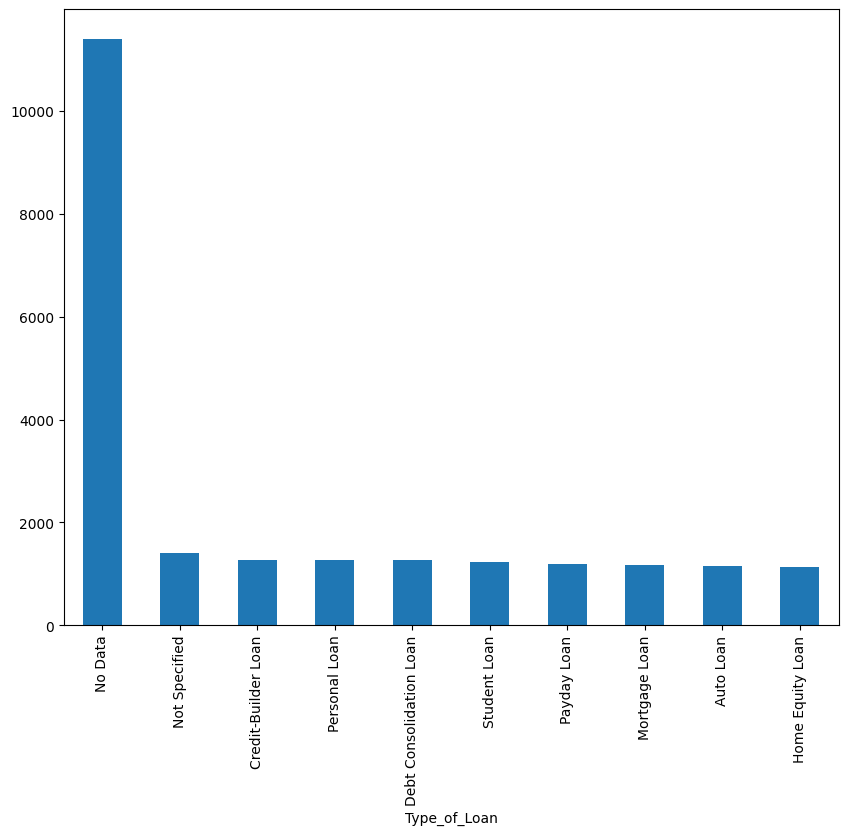

In [28]:
Top_Ten.plot(kind = 'bar',figsize = (10,8))

In [29]:
delayed = data['Payment_Behaviour'].value_counts()

In [30]:
delayed

,count
Payment_Behaviour,
Low_spent_Small_value_payments,28616
High_spent_Medium_value_payments,19738
High_spent_Large_value_payments,14726
Low_spent_Medium_value_payments,14399
High_spent_Small_value_payments,11764
Low_spent_Large_value_payments,10757


In [33]:
credit = data.groupby('Occupation')['Credit_Score'].value_counts()

In [34]:
credit

Occupation     Credit_Score
Accountant     Standard        3502
               Poor            2037
               Good            1205
Architect      Standard        3736
               Poor            1855
               Good            1233
Developer      Standard        3586
               Poor            1924
               Good            1210
Doctor         Standard        3600
               Poor            1804
               Good            1164
Engineer       Standard        3506
               Poor            2094
               Good            1264
Entrepreneur   Standard        3430
               Poor            2033
               Good            1185
Journalist     Standard        3442
               Poor            1840
               Good            1254
Lawyer         Standard        3872
               Poor            1965
               Good            1259
Manager        Standard        3386
               Poor            1856
               Good            1190
Mechanic       Standard        3625
               Poor            2044
               Good            1107
Media_Manager  Standard        3712
               Poor            1764
               Good            1244
Musician       Standard        3374
               Poor            1786
               Good            1192
Scientist      Standard        3481
               Poor            2062
               Good            1201
Teacher        Standard        3421
               Poor            2027
               Good            1224
Writer         Standard        3501
               Poor            1907
               Good             896
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

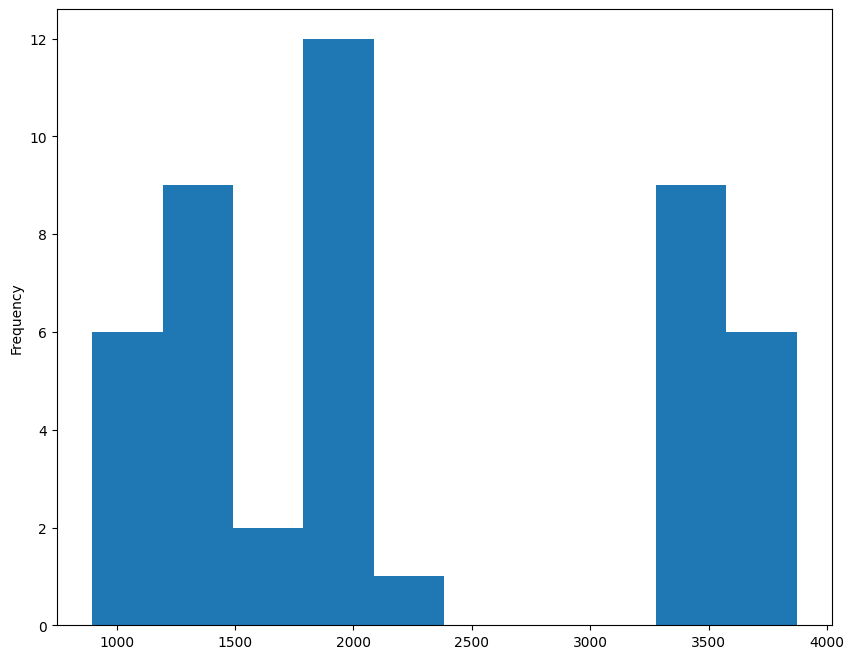

In [39]:
credit.plot(kind= 'hist',figsize = (10,8))

In [54]:
Annual = data.groupby('Occupation')['Annual_Income'].agg(['count', 'mean']).reset_index()


In [55]:
Annual

,Occupation,count,mean
0,Accountant,6744,50726.120480
1,Architect,6824,51875.392298
2,Developer,6720,50128.422143
3,Doctor,6568,49517.749976
4,Engineer,6864,50730.654073
5,Entrepreneur,6648,50987.698177
6,Journalist,6536,48430.088415
7,Lawyer,7096,49594.217396
8,Manager,6432,51466.767817
9,Mechanic,6776,50095.107550


In [56]:
dela = data.groupby('Num_Bank_Accounts')['Occupation'].value_counts()

In [57]:
dela

Num_Bank_Accounts  Occupation  
0.0                Engineer        399
                   Lawyer          356
                   Teacher         323
                   Entrepreneur    319
                   Writer          315
                                  ... 
10.0               Lawyer          296
                   Journalist      284
11.0               Journalist        4
                   Mechanic          4
                   Teacher           1
Name: count, Length: 168, dtype: int64